In [10]:
# =========================
# IMPORT REQUIRED LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import warnings
from wordcloud import WordCloud

# Ignore unnecessary warnings
warnings.filterwarnings("ignore")

# Display plots inside notebook
%matplotlib inline

In [11]:
# =========================
# LOAD DATASETS
# =========================

# Load fake news dataset
fake_df = pd.read_csv("../data/Fake.csv")

# Load true news dataset
true_df = pd.read_csv("../data/True.csv")

# Display first 5 rows
print("FAKE NEWS DATASET")
display(fake_df.head())

print("\nTRUE NEWS DATASET")
display(true_df.head())

FAKE NEWS DATASET


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



TRUE NEWS DATASET


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [12]:
# =========================
# DATASET SHAPE ANALYSIS
# =========================

# Display dataset shapes
print("FAKE DATASET SHAPE:", fake_df.shape)
print("TRUE DATASET SHAPE:", true_df.shape)

# Display column names
print("\nFAKE DATASET COLUMNS:")
print(fake_df.columns)

print("\nTRUE DATASET COLUMNS:")
print(true_df.columns)

FAKE DATASET SHAPE: (23481, 4)
TRUE DATASET SHAPE: (21417, 4)

FAKE DATASET COLUMNS:
Index(['title', 'text', 'subject', 'date'], dtype='str')

TRUE DATASET COLUMNS:
Index(['title', 'text', 'subject', 'date'], dtype='str')


In [13]:
# =========================
# ADD TARGET LABELS
# =========================

# Add label to fake news dataset
fake_df["label"] = 0

# Add label to true news dataset
true_df["label"] = 1

# Display updated datasets
print("FAKE NEWS DATASET WITH LABEL")
display(fake_df.head())

print("\nTRUE NEWS DATASET WITH LABEL")
display(true_df.head())

FAKE NEWS DATASET WITH LABEL


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0



TRUE NEWS DATASET WITH LABEL


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [14]:
# =========================
# MERGE AND SHUFFLE DATASETS
# =========================

# Combine fake and true datasets
news_df = pd.concat([fake_df, true_df], axis=0)

# Shuffle dataset randomly
news_df = news_df.sample(frac=1)

# Reset index
news_df.reset_index(drop=True, inplace=True)

# Display dataset information
print("FINAL DATASET SHAPE:", news_df.shape)

# Display first 5 rows
display(news_df.head())

FINAL DATASET SHAPE: (44898, 5)


,title,text,subject,date,label
0,The Adoration Of Kim Jong Un,PYONGYANG - North Koreans stage a demonstratio...,worldnews,"November 30, 2017",1
1,India defends ties with North Korea in talks w...,NEW DELHI (Reuters) - India s foreign minister...,worldnews,"October 25, 2017",1
2,U.S. diplomats accuse Tillerson of breaking ch...,WASHINGTON (Reuters) - A group of about a doze...,politicsNews,"November 21, 2017",1
3,Trump Chooses Racist Anti-Gay Alabama Senator...,Donald Trump just selected a racist homophobe ...,News,"November 18, 2016",0
4,U.S. judge refuses to halt New York nuclear po...,NEW YORK (Reuters) - A federal judge on Tuesda...,politicsNews,"July 25, 2017",1


In [15]:
# =========================
# CHECK MISSING VALUES
# =========================

# Check null values in dataset
missing_values = news_df.isnull().sum()

print("MISSING VALUES IN DATASET:\n")
print(missing_values)

MISSING VALUES IN DATASET:

title      0
text       0
subject    0
date       0
label      0
dtype: int64


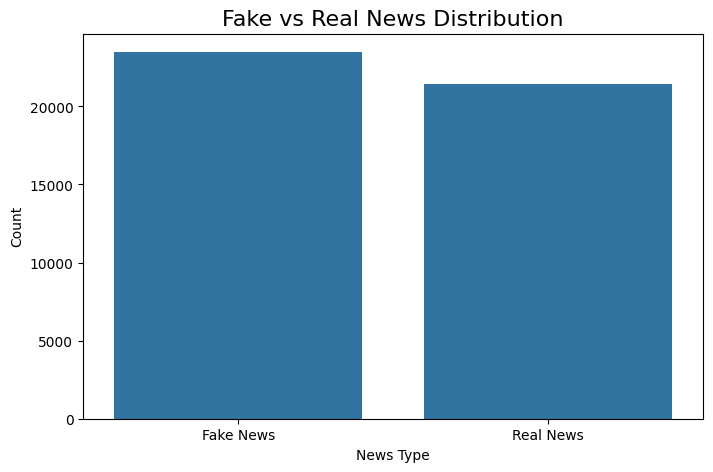

In [16]:
# =========================
# LABEL DISTRIBUTION VISUALIZATION
# =========================

# Create figure
plt.figure(figsize=(8, 5))

# Plot label counts
sns.countplot(x='label', data=news_df)

# Add chart title
plt.title("Fake vs Real News Distribution", fontsize=16)

# Add x-axis labels
plt.xticks([0, 1], ["Fake News", "Real News"])

# Add axis labels
plt.xlabel("News Type")
plt.ylabel("Count")

# Display chart
plt.show()

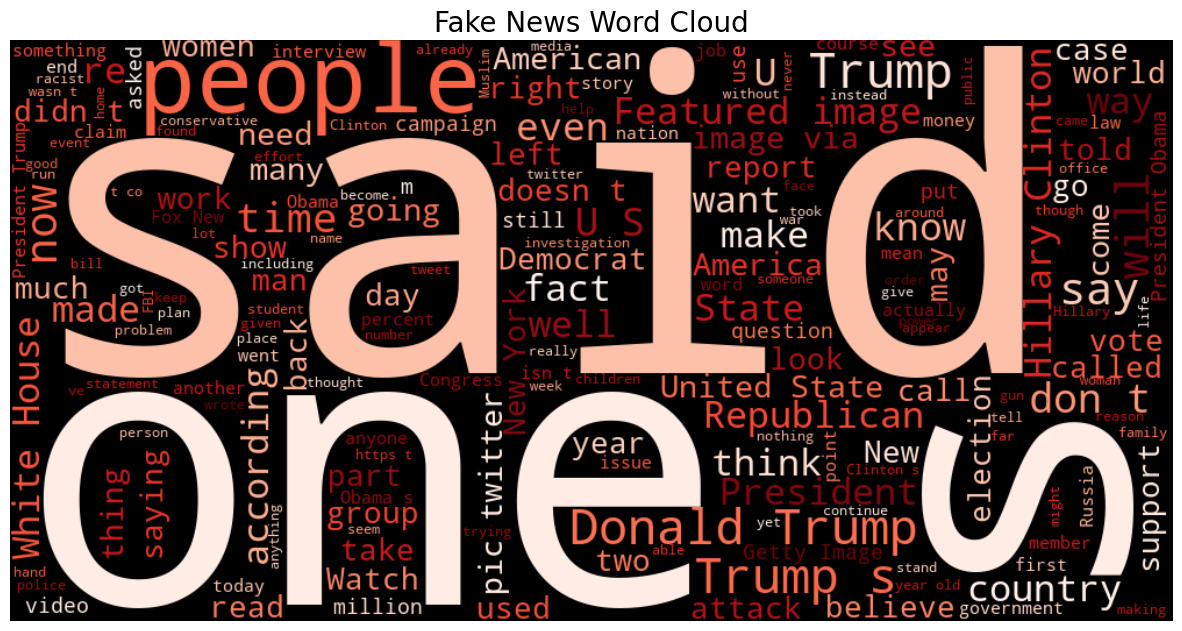

In [17]:
# =========================
# FAKE NEWS WORD CLOUD
# =========================

# Combine all fake news text
fake_text = " ".join(news_df[news_df["label"] == 0]["text"])

# Generate word cloud
fake_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black',
    colormap='Reds'
).generate(fake_text)

# Display word cloud
plt.figure(figsize=(15, 8))

plt.imshow(fake_wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Fake News Word Cloud", fontsize=20)

plt.show()

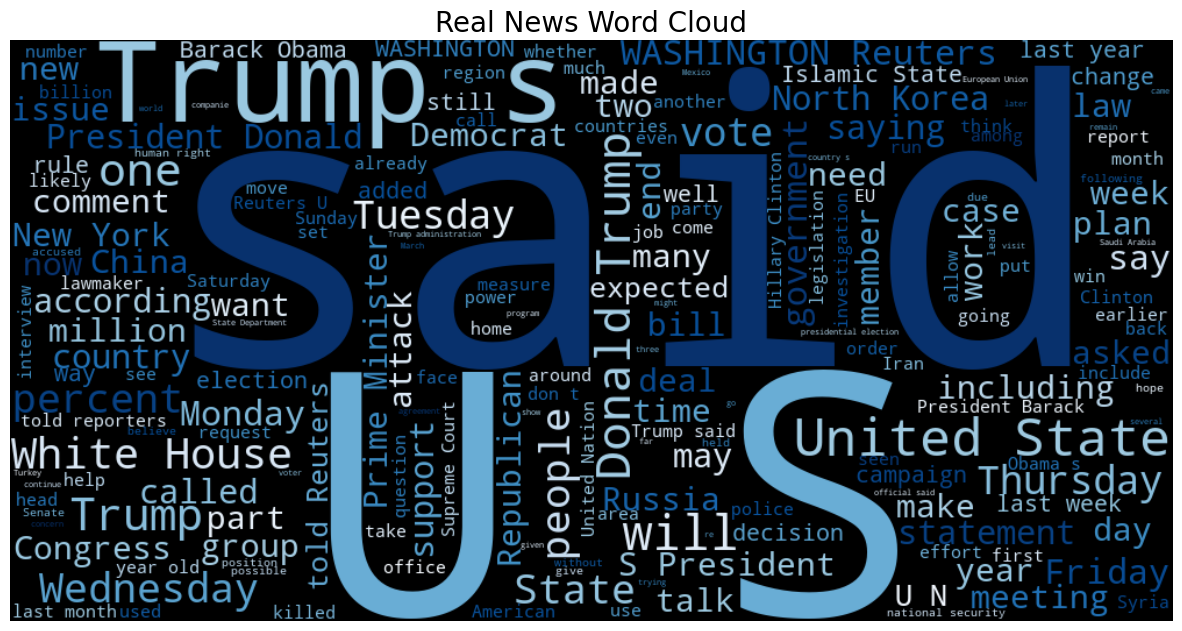

In [18]:
# =========================
# REAL NEWS WORD CLOUD
# =========================

# Combine all real news text
real_text = " ".join(news_df[news_df["label"] == 1]["text"])

# Generate word cloud
real_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='black',
    colormap='Blues'
).generate(real_text)

# Display word cloud
plt.figure(figsize=(15, 8))

plt.imshow(real_wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Real News Word Cloud", fontsize=20)

plt.show()

In [19]:
# =========================
# DOWNLOAD NLP RESOURCES
# =========================

# Download stopwords
nltk.download('stopwords')

# Download punkt tokenizer
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [20]:
# =========================
# IMPORT NLP TOOLS
# =========================

import re
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Initialize stemming
port_stem = PorterStemmer()

# Load English stopwords
stop_words = stopwords.words('english')

# =========================
# TEXT CLEANING FUNCTION
# =========================

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove text inside square brackets
    text = re.sub(r'\[.*?\]', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>+', '', text)

    # Remove punctuation
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)

    # Remove newline characters
    text = re.sub(r'\n', '', text)

    # Remove words containing numbers
    text = re.sub(r'\w*\d\w*', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and apply stemming
    cleaned_words = []

    for word in words:

        if word not in stop_words:

            stemmed_word = port_stem.stem(word)

            cleaned_words.append(stemmed_word)

    # Join cleaned words
    return " ".join(cleaned_words)

In [21]:
# =========================
# TEST TEXT CLEANING
# =========================

# Sample news text
sample_text = """
Donald Trump is speaking at the White House!!!
Visit https://news.com for more updates.
"""

# Display original text
print("ORIGINAL TEXT:\n")
print(sample_text)

# Clean text
cleaned_text = clean_text(sample_text)

# Display cleaned text
print("\nCLEANED TEXT:\n")
print(cleaned_text)

ORIGINAL TEXT:


Donald Trump is speaking at the White House!!!
Visit https://news.com for more updates.


CLEANED TEXT:

donald trump speak white housevisit updat


In [23]:
# =========================
# FAST NLP CLEANING
# =========================

# Create smaller sample first for testing
sample_news_df = news_df.head(4000).copy()

# Apply cleaning
sample_news_df["clean_text"] = sample_news_df["text"].apply(clean_text)

# Display preview
print("CLEANING COMPLETED SUCCESSFULLY\n")

display(sample_news_df[["text", "clean_text"]].head())

CLEANING COMPLETED SUCCESSFULLY



,text,clean_text
0,PYONGYANG - North Koreans stage a demonstratio...,pyongyang north korean stage demonstr devot le...
1,NEW DELHI (Reuters) - India s foreign minister...,new delhi reuter india foreign minist defend c...
2,WASHINGTON (Reuters) - A group of about a doze...,washington reuter group dozen us state depart ...
3,Donald Trump just selected a racist homophobe ...,donald trump select racist homophob nation lea...
4,NEW YORK (Reuters) - A federal judge on Tuesda...,new york reuter feder judg tuesday dismiss law...


In [24]:
# =========================
# FEATURE AND LABEL CREATION
# =========================

# Features (input text)
X = sample_news_df["clean_text"]

# Labels (target values)
y = sample_news_df["label"]

# Display information
print("FEATURES SHAPE:", X.shape)
print("LABELS SHAPE:", y.shape)

print("\nFIRST CLEANED NEWS ARTICLE:\n")
print(X.iloc[0])

print("\nFIRST LABEL:")
print(y.iloc[0])

FEATURES SHAPE: (4000,)
LABELS SHAPE: (4000,)

FIRST CLEANED NEWS ARTICLE:

pyongyang north korean stage demonstr devot leader kim jong un least year larg ceremoni squar pyongyang mansa peopl call parad past old stand balconi live long decemb kim mark six year power time purg execut around peopl accord institut nation secur strategi think tank south korea nation intellig servic ni peopl parad carri flower includ north korea nation bloom kimilsungia kimjongilia special creat honor kim grandfath father kim il sung kim jong il north korea socialist countri pass power famili line imag former presid pin left side everi jacket dress worn close wearer heart privat convers north korean quietli lament shortcom system bureaucrat take long get thing done disorgan say dare openli critic suprem leader north korea gdp per capita estim cia factbook place world poorer haiti zimbabw afghanistan defector say mani north korean lead doubl live earn money unoffici market place supplement state incom leader

In [25]:
# =========================
# IMPORT TF-IDF VECTORIZER
# =========================

from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF IMPORTED SUCCESSFULLY")

TF-IDF IMPORTED SUCCESSFULLY


In [26]:
# =========================
# TF-IDF FEATURE EXTRACTION
# =========================

# Create TF-IDF object
vectorizer = TfidfVectorizer(max_features=5000)

# Convert cleaned text into vectors
X_vectorized = vectorizer.fit_transform(X)

# Display vectorized shape
print("TF-IDF VECTORIZATION COMPLETED")

print("\nVECTOR SHAPE:")
print(X_vectorized.shape)

TF-IDF VECTORIZATION COMPLETED

VECTOR SHAPE:
(4000, 5000)


In [27]:
# =========================
# IMPORT TRAIN TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

print("TRAIN TEST SPLIT IMPORTED SUCCESSFULLY")

TRAIN TEST SPLIT IMPORTED SUCCESSFULLY


In [28]:
# =========================
# SPLIT DATASET
# =========================

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

# Display shapes
print("TRAIN TEST SPLIT COMPLETED")

print("\nTRAINING DATA SHAPE:")
print(X_train.shape)

print("\nTESTING DATA SHAPE:")
print(X_test.shape)

TRAIN TEST SPLIT COMPLETED

TRAINING DATA SHAPE:
(3200, 5000)

TESTING DATA SHAPE:
(800, 5000)


In [29]:
# =========================
# IMPORT LOGISTIC REGRESSION
# =========================

from sklearn.linear_model import LogisticRegression

print("LOGISTIC REGRESSION IMPORTED SUCCESSFULLY")

LOGISTIC REGRESSION IMPORTED SUCCESSFULLY


In [30]:
# =========================
# TRAIN LOGISTIC REGRESSION MODEL
# =========================

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

print("MODEL TRAINING COMPLETED SUCCESSFULLY")

MODEL TRAINING COMPLETED SUCCESSFULLY


In [31]:
# =========================
# MAKE PREDICTIONS
# =========================

# Predict on test data
y_pred = model.predict(X_test)

print("PREDICTIONS COMPLETED")

PREDICTIONS COMPLETED


In [32]:
# =========================
# IMPORT EVALUATION METRICS
# =========================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("EVALUATION METRICS IMPORTED")

EVALUATION METRICS IMPORTED


In [33]:
# =========================
# CALCULATE ACCURACY
# =========================

accuracy = accuracy_score(y_test, y_pred)

print("MODEL ACCURACY:")
print(round(accuracy * 100, 2), "%")

MODEL ACCURACY:
98.12 %


In [34]:
# =========================
# CLASSIFICATION REPORT
# =========================

print("CLASSIFICATION REPORT:\n")

print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       405
           1       0.97      0.99      0.98       395

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



In [35]:
# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

print("CONFUSION MATRIX:\n")
print(cm)

CONFUSION MATRIX:

[[395  10]
 [  5 390]]


In [37]:
# =========================
# SAVE MODEL AND VECTORIZER
# =========================

import pickle

# Save trained model
with open("../models/fake_news_model.pkl", "wb") as model_file:
    pickle.dump(model, model_file)

# Save TF-IDF vectorizer
with open("../models/tfidf_vectorizer.pkl", "wb") as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)

print("MODEL AND VECTORIZER SAVED SUCCESSFULLY")

MODEL AND VECTORIZER SAVED SUCCESSFULLY
